<a href="https://colab.research.google.com/github/vinodiniilam/Textile_Fabric_Classification/blob/main/Textile_Fabric_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir('/content/drive/MyDrive/DATASET'))

['archive.zip', 'cnn_textile_model.h5']


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/DATASET/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['train', 'valid', 'README.dataset.txt', 'test', 'README.roboflow.txt']


In [ ]:
import os

print("Train classes:")
print(os.listdir('/content/dataset/train'))

print("\nValidation classes:")
print(os.listdir('/content/dataset/valid'))

print("\nTest classes:")
print(os.listdir('/content/dataset/test'))

Train classes:
['Bandhani', 'Pichwai', 'Ikat', 'Banarasi']

Validation classes:
['Bandhani', 'Pichwai', 'Ikat', 'Banarasi']

Test classes:
['Bandhani', 'Pichwai', 'Ikat', 'Banarasi']


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/valid',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Dataset loaded successfully!")

Found 1293 files belonging to 4 classes.
Found 115 files belonging to 4 classes.
Found 60 files belonging to 4 classes.
Dataset loaded successfully!


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.3619 - loss: 1.3012 - val_accuracy: 0.4783 - val_loss: 1.1653
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.4687 - loss: 1.1339 - val_accuracy: 0.4870 - val_loss: 1.1076
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.5994 - loss: 0.9465 - val_accuracy: 0.6087 - val_loss: 0.9464
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7169 - loss: 0.7231 - val_accuracy: 0.6435 - val_loss: 0.8851
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.7943 - loss: 0.5450 - val_accuracy: 0.7130 - val_loss: 0.8612
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.8600 - loss: 0.3726 - val_accuracy: 0.7478 - val_loss: 0.9684
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9103 - loss: 0.2515 - val_accuracy: 0.7652 - val_loss: 0.9414
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9358 - loss: 0.1796 - val_accuracy: 0.7913 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 901ms/step - accuracy: 0.7000 - loss: 2.5096
Test Loss: 2.5096161365509033
Test Accuracy: 0.699999988079071


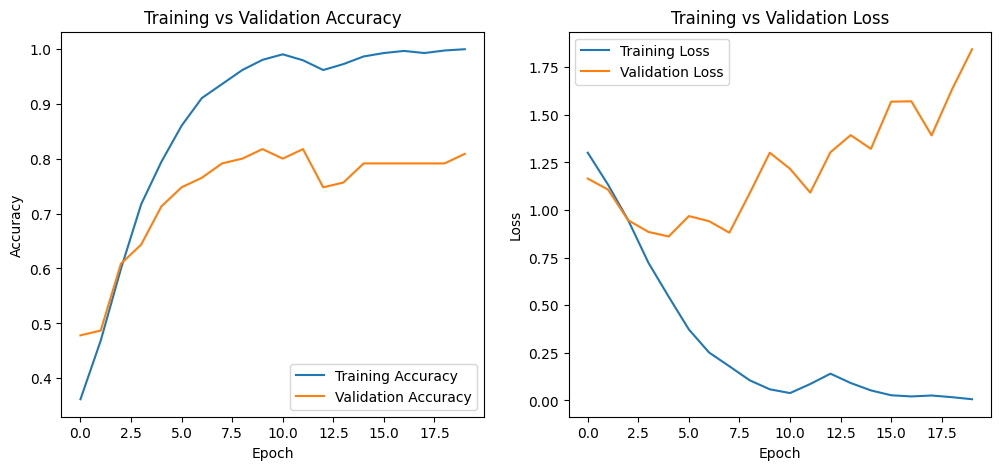

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [ ]:
model.save('/content/drive/MyDrive/DATASET/cnn_textile_model.h5')

print("Model saved successfully!")

Model saved successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
Actual: Ikat
Predicted: Pichwai
--------------------


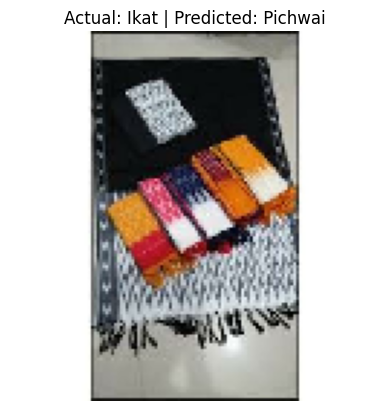

Actual: Bandhani
Predicted: Banarasi
--------------------


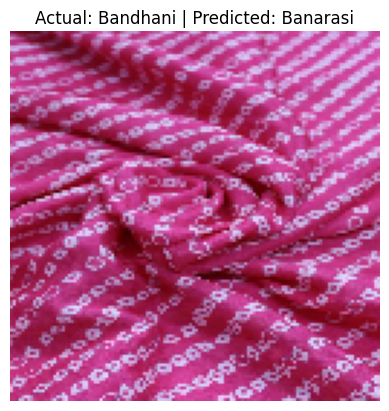

Actual: Banarasi
Predicted: Banarasi
--------------------


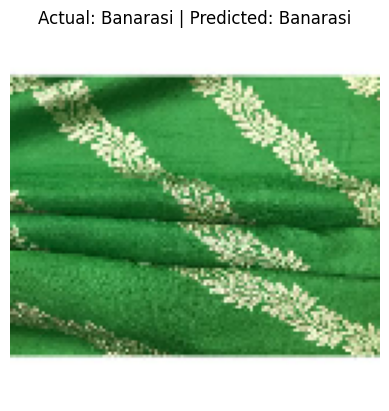

Actual: Banarasi
Predicted: Banarasi
--------------------


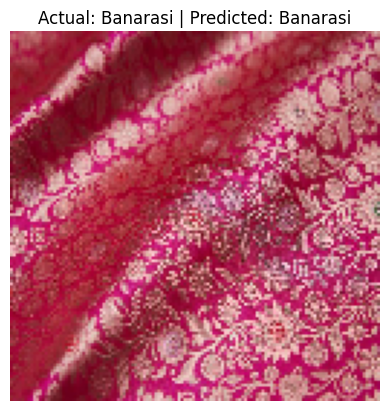

Actual: Pichwai
Predicted: Pichwai
--------------------


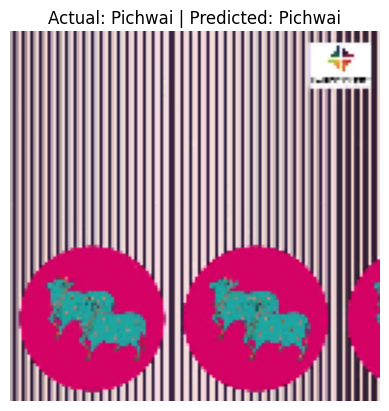

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_names = train_data.class_names

for images, labels in test_data.take(1):
    predictions = model.predict(images)

    for i in range(5):
        predicted_class = class_names[np.argmax(predictions[i])]
        actual_class = class_names[labels[i].numpy()]

        print("Actual:", actual_class)
        print("Predicted:", predicted_class)
        print("--------------------")

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Actual: {actual_class} | Predicted: {predicted_class}")
        plt.axis("off")
        plt.show()

In [ ]:


y_true = []
y_pred = []

for images, labels in test_data:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

class_names = test_data.class_names

In [ ]:

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Banarasi       0.75      0.64      0.69        14
    Bandhani       0.73      0.73      0.73        15
        Ikat       0.50      0.69      0.58        13
     Pichwai       0.87      0.72      0.79        18

    accuracy                           0.70        60
   macro avg       0.71      0.70      0.70        60
weighted avg       0.73      0.70      0.71        60



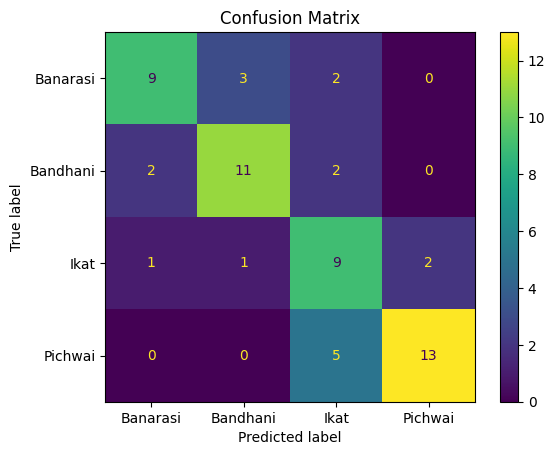

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()